
# Deep Learning Lab Assignment 1 - Neural Network From Scratch



Name: Vedant Arun Nakshane

PRN:202201040147

Roll No: 64

Batch: DL3



#Task 1
Objective And Dataset Selection

Dataset Link:https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

#Import Necessary libraries

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt

In [ ]:
# Load Breast Cancer dataset
data = load_breast_cancer()
X = data.data  # Features
y = data.target.reshape(-1, 1)  # Labels

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encode the labels
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Get the actual number of features from the training data
input_size = X_train.shape[1]  # Update input_size based on actual data

# Initialize weights and biases with random values
hidden_size = 10
output_size = 2

np.random.seed(42)  # For reproducibility

W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

print("Neural network initialized!")

Neural network initialized!


# Neural Network Architecture
# -----------------------------------


Architecture:
- Input Layer: 30 neurons (corresponding to 30 features)
- Hidden Layer: 10 neurons (using Sigmoid activation function)
- Output Layer: 2 neurons (using Softmax activation function for classification)

# Activation functions and their derivatives

In [ ]:
def sigmoid(x):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    """Derivative of sigmoid function for backpropagation."""
    return sigmoid(x) * (1 - sigmoid(x))

def softmax(x):
    """Softmax activation function for output layer."""
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def cross_entropy_loss(y_true, y_pred):
    """Cross-entropy loss function for classification."""
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))

# Initialize weights and biases with random values
input_size = 30
hidden_size = 10
output_size = 2

np.random.seed(42)  # For reproducibility

W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

print("Neural network initialized!")

Neural network initialized!


#Training Parameters

In [ ]:
learning_rate = 0.01
epochs = 500
losses = []

#Training Loop

Starting training...
Epoch 50/500, Loss: 0.0469
Epoch 100/500, Loss: 0.0281
Epoch 150/500, Loss: 0.0190
Epoch 200/500, Loss: 0.0140
Epoch 250/500, Loss: 0.0108
Epoch 300/500, Loss: 0.0086
Epoch 350/500, Loss: 0.0071
Epoch 400/500, Loss: 0.0060
Epoch 450/500, Loss: 0.0052
Epoch 500/500, Loss: 0.0045
Training completed!


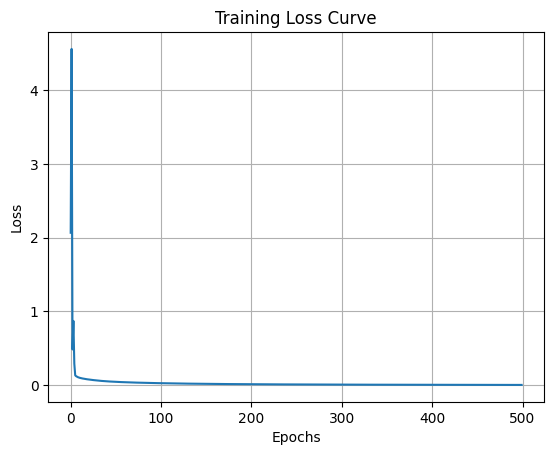

In [ ]:
print("Starting training...")

for epoch in range(epochs):
    # Forward Pass
    Z1 = np.dot(X_train, W1) + b1
    A1 = sigmoid(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)

    # Compute Loss
    loss = cross_entropy_loss(y_train, A2)
    losses.append(loss)

    # Backward Pass
    dZ2 = A2 - y_train
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * sigmoid_derivative(Z1)
    dW1 = np.dot(X_train.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # Update Weights and Biases
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    # Print loss every 50 epochs
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

print("Training completed!")

# Plot the Loss Curve
plt.plot(losses)
plt.title('Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.show()

#Evaluation on Test Data

In [ ]:
print("Evaluating model on test data...")

# Forward pass on test data
Z1_test = np.dot(X_test, W1) + b1
A1_test = sigmoid(Z1_test)
Z2_test = np.dot(A1_test, W2) + b2
A2_test = softmax(Z2_test)

# Predictions
predictions = np.argmax(A2_test, axis=1)
true_labels = np.argmax(y_test, axis=1)

# Accuracy
accuracy = np.mean(predictions == true_labels)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Evaluating model on test data...
Test Accuracy: 96.49%


I Vedant Nakshane confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines.
The code is uploaded on my GitHub repository account, and the repository link is provided below:

GitHub Repository Link:https://github.com/vedant7001/DL_Assign

Signature: Vedant Arun Nakshane